# Tarea 6 — Teoría Posmoderna de Portafolios

**Integrantes:**  
- Sara Hernandez Ochoa  
- Miguel Aaron Castillón Ochoa

---

## Introducción

En esta actividad se implementan tres métodos de optimización de portafolios basados en la **Teoría Posmoderna de Portafolios (TPMP)**: mínima semivarianza, máximo ratio Omega y semivarianza objetivo (*target semivariance*).

A diferencia de la Teoría Moderna de Portafolios (TMP) de Markowitz, la TPMP distingue entre el riesgo a la baja (*downside risk*) y el potencial de ganancia (*upside risk*), lo que permite construir portafolios que minimizan pérdidas sin penalizar los rendimientos positivos.

La optimización se realiza con `scipy.optimize.minimize` en lugar de simulación de Montecarlo.

## 1. Importación de librerías

In [13]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

## 2. Descarga de datos

Se seleccionaron **5 activos de renta variable** de distintos sectores defensivos y de crecimiento, todos listados en bolsas de EE.UU.:

| Ticker | Empresa | Sector |
|--------|---------|--------|
| COST | Costco Wholesale | Consumer Staples |
| PFE | Pfizer | Health Care |
| WMT | Walmart | Consumer Staples |
| DUK | Duke Energy | Utilities |
| JNJ | Johnson & Johnson | Health Care |

Como **benchmark** se utiliza **VOO** (Vanguard S&P 500 ETF), un ETF de renta variable ampliamente utilizado como referencia del mercado accionario estadounidense, consistente con la naturaleza de equity de los activos seleccionados.

Período de análisis: **2010-01-01 a 2026-01-01** (según especificaciones de la tarea).

In [14]:
# Parámetros
start_date = '2010-01-01'
end_date   = '2026-01-01'

tickers   = ['COST', 'PFE', 'WMT', 'DUK', 'JNJ']
benchmark_ticker = 'VOO'

# Descarga de precios
prices = yf.download(tickers, start=start_date, end=end_date)['Close'].dropna()
prices_bench = yf.download(benchmark_ticker, start=start_date, end=end_date)['Close'].dropna()

print(f"Observaciones: {len(prices)} días")
print(f"Activos: {list(prices.columns)}")
prices.tail()

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


Observaciones: 4024 días
Activos: ['COST', 'DUK', 'JNJ', 'PFE', 'WMT']


Ticker,COST,DUK,JNJ,PFE,WMT
Date,,,,,
2025-12-24,870.670532,116.487885,206.681259,24.617630,111.610001
2025-12-26,872.158447,116.190414,206.532059,24.676640,111.739998
2025-12-29,866.656067,116.527534,206.462418,24.588123,112.529999
2025-12-30,864.469055,116.686188,205.815857,24.578287,111.919998
2025-12-31,861.163574,116.220161,205.855652,24.489771,111.410004


In [15]:
# Rendimientos diarios
rets  = prices.pct_change().dropna()
rets_bench = prices_bench.pct_change().dropna()

# Alinear fechas benchmark con portafolio
rets_bench = rets_bench.reindex(rets.index).dropna()
rets = rets.reindex(rets_bench.index)

print(f"Observaciones alineadas: {len(rets)}")
rets.describe().round(4)

Observaciones alineadas: 3851


Ticker,COST,DUK,JNJ,PFE,WMT
count,3851.0000,3851.0000,3851.0000,3851.0000,3851.0000
mean,0.0009,0.0004,0.0005,0.0004,0.0006
std,0.0128,0.0117,0.0107,0.0139,0.0125
min,-0.1245,-0.1150,-0.1004,-0.0773,-0.1138
25%,-0.0055,-0.0053,-0.0045,-0.0065,-0.0052
50%,0.0009,0.0007,0.0004,0.0000,0.0007
75%,0.0075,0.0066,0.0058,0.0072,0.0066
max,0.0996,0.1230,0.0800,0.1086,0.1171


## 3. Implementación de funciones de optimización

Cada función recibe los **rendimientos** (y el benchmark en su caso), y regresa únicamente los **pesos óptimos** del portafolio.  
Internamente se usa `scipy.optimize.minimize` con el método `SLSQP`, restricción de suma de pesos = 1 y sin posiciones cortas (w ≥ 0).

---

### 3.1 Función auxiliar: condiciones del optimizador

In [16]:
def _get_constraints_bounds(n):
    """Restricciones y límites comunes para los tres métodos."""
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    return constraints, bounds


def _run_optimizer(objective, w0, args, constraints, bounds):
    """Ejecuta la minimización con múltiples puntos de inicio para evitar mínimos locales."""
    n = len(w0)
    best_res = None
    np.random.seed(42)
    
    # 50 puntos de inicio aleatorios (le metemos 'ponche' a la optimización)
    for _ in range(50):
        w_init = np.random.dirichlet(np.ones(n))
        res = minimize(
            objective,
            w_init,
            args=args,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': 1e-12, 'maxiter': 1000}
        )
        if res.success:
            if best_res is None or res.fun < best_res.fun:
                best_res = res
    
    # Si ninguno convergió, tomar el mejor de igual forma
    if best_res is None:
        best_res = minimize(objective, w0, args=args, method='SLSQP',
                            bounds=bounds, constraints=constraints)
    return best_res

### 3.2 Mínima Semivarianza

Minimiza la semivarianza del portafolio, penalizando **únicamente los rendimientos negativos**:

$$\min_w \quad \sigma_d^2 = \mathbb{E}[\min(r_p, 0)^2]$$

$$\text{s.a.} \quad \sum_i w_i = 1, \quad w_i \geq 0$$

In [17]:
def min_semivariance(rets):
    """
    Optimiza el portafolio de Mínima Semivarianza.
    
    Parámetros
    ----------
    rets : pd.DataFrame
        Rendimientos diarios de los activos (T x N).
    
    Retorna
    -------
    np.ndarray : Pesos óptimos del portafolio.
    """
    n = rets.shape[1]
    constraints, bounds = _get_constraints_bounds(n)
    
    def objective(w):
        rp = rets.values @ w
        downside = np.minimum(rp, 0)
        return np.mean(downside ** 2)
    
    w0 = np.ones(n) / n
    res = _run_optimizer(objective, w0, args=(), constraints=constraints, bounds=bounds)
    return res.x, res.fun

### 3.3 Máximo Ratio Omega

Maximiza el ratio Omega del portafolio, definido como la razón entre el upside y el downside:

$$\max_w \quad \Omega_p = \frac{\sum \max(r_p, 0)}{\sum |\min(r_p, 0)|}$$

$$\text{s.a.} \quad \sum_i w_i = 1, \quad w_i \geq 0$$

In [18]:
def max_omega(rets):
    """
    Optimiza el portafolio de Máximo Ratio Omega.
    
    Parámetros
    ----------
    rets : pd.DataFrame
        Rendimientos diarios de los activos (T x N).
    
    Retorna
    -------
    np.ndarray : Pesos óptimos del portafolio.
    """
    n = rets.shape[1]
    constraints, bounds = _get_constraints_bounds(n)
    
    def objective(w):
        rp = rets.values @ w
        gains  = np.maximum(rp, 0).sum()
        losses = -np.minimum(rp, 0).sum()
        if losses < 1e-10:
            return -1e10
        return -(gains / losses)   # negativo porque minimize minimiza
    
    w0 = np.ones(n) / n
    res = _run_optimizer(objective, w0, args=(), constraints=constraints, bounds=bounds)
    return res.x, -res.fun        # regresamos Omega positivo

### 3.4 Mínima Semivarianza Objetivo (*Target Semivariance*)

Minimiza el riesgo de quedar **por debajo del benchmark**, penalizando únicamente cuando el portafolio rinde menos que el índice de referencia:

$$\min_w \quad \sigma_{target}^2 = \mathbb{E}[\min(r_p - r_{bench}, 0)^2]$$

$$\text{s.a.} \quad \sum_i w_i = 1, \quad w_i \geq 0$$

In [19]:
def min_target_semivariance(rets, rets_benchmark):
    """
    Optimiza el portafolio de Mínima Semivarianza Objetivo (Target Semivariance).
    
    Parámetros
    ----------
    rets : pd.DataFrame
        Rendimientos diarios de los activos (T x N).
    rets_benchmark : pd.Series
        Rendimientos diarios del benchmark (T,).
    
    Retorna
    -------
    np.ndarray : Pesos óptimos del portafolio.
    """
    n = rets.shape[1]
    constraints, bounds = _get_constraints_bounds(n)
    bench = rets_benchmark.values.flatten()
    
    def objective(w):
        rp = rets.values @ w
        downside = np.minimum(rp - bench, 0)
        return np.mean(downside ** 2)
    
    w0 = np.ones(n) / n
    res = _run_optimizer(objective, w0, args=(), constraints=constraints, bounds=bounds)
    return res.x, res.fun

## 4. Optimización del portafolio

Se aplican las tres funciones al portafolio de 5 activos.

In [20]:
# ── Mínima Semivarianza ──────────────────────────────────────────────────────
w_sv, val_sv = min_semivariance(rets)

# ── Máximo Omega ─────────────────────────────────────────────────────────────
w_om, val_om = max_omega(rets)

# ── Mínima Semivarianza Objetivo (benchmark: VOO) ─────────────────────────────
w_ts, val_ts = min_target_semivariance(rets, rets_bench)

print("Optimización completada ✓")

Optimización completada ✓


### 4.1 Pesos óptimos y valores de la función objetivo

In [21]:
# Tabla de resultados
results = pd.DataFrame({
    'Min. Semivarianza': w_sv,
    'Máx. Omega': w_om,
    'Min. Semivar. Target': w_ts
}, index=tickers)

print("=" * 55)
print("        PESOS ÓPTIMOS (%)        ")
print("=" * 55)
print((results * 100).round(2).to_string())
print()
print("=" * 55)
print("VALORES DE FUNCIÓN OBJETIVO")
print("=" * 55)
print(f"  Mínima Semivarianza      : {val_sv:.8f}")
print(f"  Máximo Omega (ratio)     : {val_om:.4f}")
print(f"  Semivar. Target (vs VOO) : {val_ts:.8f}")
print()
print("Verificación de suma de pesos:")
print(f"  Min. Semivarianza  → {np.sum(w_sv):.6f}")
print(f"  Máx. Omega         → {np.sum(w_om):.6f}")
print(f"  Min. Target Svvar. → {np.sum(w_ts):.6f}")

        PESOS ÓPTIMOS (%)        
      Min. Semivarianza  Máx. Omega  Min. Semivar. Target
COST              13.47       50.83                 32.35
PFE               25.61       11.62                 16.50
WMT               29.52       22.06                 23.18
DUK                9.48        0.00                 17.85
JNJ               21.91       15.49                 10.13

VALORES DE FUNCIÓN OBJETIVO
  Mínima Semivarianza      : 0.00003424
  Máximo Omega (ratio)     : 1.2330
  Semivar. Target (vs VOO) : 0.00002789

Verificación de suma de pesos:
  Min. Semivarianza  → 1.000000
  Máx. Omega         → 1.000000
  Min. Target Svvar. → 1.000000


### 4.2 Visualización de pesos

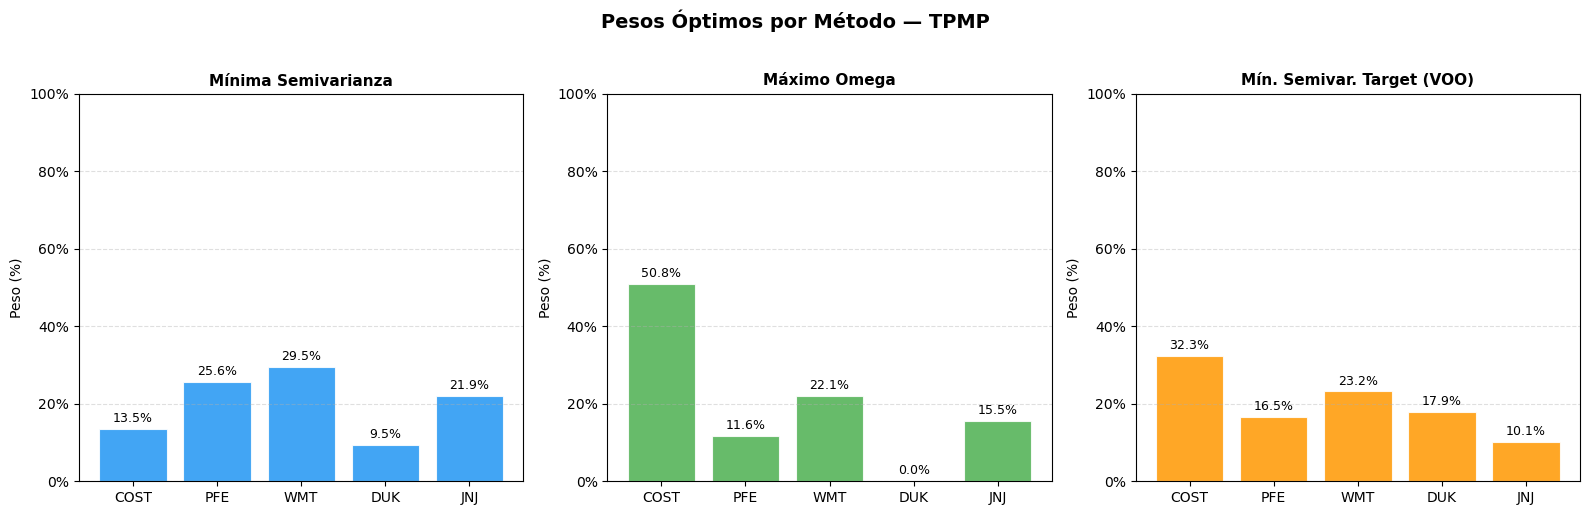

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pesos Óptimos por Método — TPMP', fontsize=14, fontweight='bold', y=1.02)

titulos = ['Mínima Semivarianza', 'Máximo Omega', 'Mín. Semivar. Target (VOO)']
pesos   = [w_sv, w_om, w_ts]
colores = ['#2196F3', '#4CAF50', '#FF9800']

for ax, titulo, w, color in zip(axes, titulos, pesos, colores):
    bars = ax.bar(tickers, w * 100, color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Peso (%)')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, val in zip(bars, w):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 4.3 Comparación de rendimientos acumulados

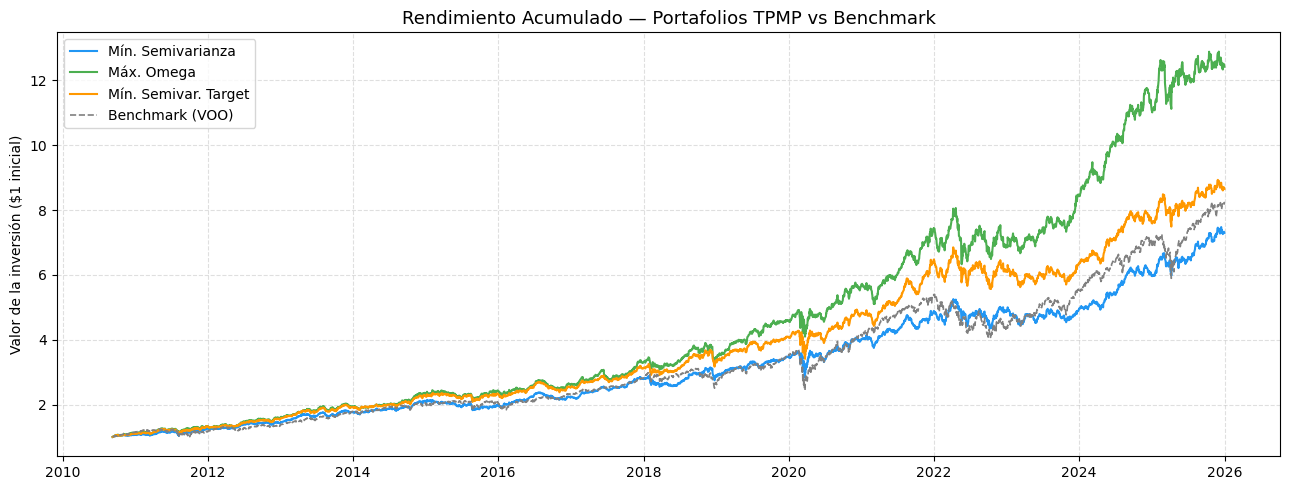

In [23]:
# Rendimientos del portafolio con cada método
rp_sv = (rets.values @ w_sv)
rp_om = (rets.values @ w_om)
rp_ts = (rets.values @ w_ts)
rb    = rets_bench.values.flatten()

# Acumulados
cum_sv = (1 + rp_sv).cumprod()
cum_om = (1 + rp_om).cumprod()
cum_ts = (1 + rp_ts).cumprod()
cum_b  = (1 + rb).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(rets.index, cum_sv, label='Mín. Semivarianza',      color='#2196F3', lw=1.5)
ax.plot(rets.index, cum_om, label='Máx. Omega',              color='#4CAF50', lw=1.5)
ax.plot(rets.index, cum_ts, label='Mín. Semivar. Target',   color='#FF9800', lw=1.5)
ax.plot(rets.index, cum_b,  label='Benchmark (VOO)',         color='gray',    lw=1.2, linestyle='--')
ax.set_title('Rendimiento Acumulado — Portafolios TPMP vs Benchmark', fontsize=13)
ax.set_ylabel('Valor de la inversión ($1 inicial)')
ax.legend()
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 4.4 Métricas de riesgo-rendimiento

In [24]:
def metricas(rp, nombre):
    ann_ret  = np.mean(rp) * 252
    ann_std  = np.std(rp) * np.sqrt(252)
    downside = np.minimum(rp, 0)
    semivar  = np.mean(downside**2)
    semi_std = np.sqrt(semivar) * np.sqrt(252)
    sharpe   = ann_ret / ann_std if ann_std > 0 else 0
    gains    = np.maximum(rp, 0).sum()
    losses   = -np.minimum(rp, 0).sum()
    omega    = gains / losses if losses > 0 else np.inf
    return {'Método': nombre,
            'Rend. Anual (%)': round(ann_ret*100, 2),
            'Vol. Anual (%)':  round(ann_std*100, 2),
            'Semivarianza':    round(semivar, 8),
            'Semi-Desv. Anual (%)': round(semi_std*100, 2),
            'Sharpe':          round(sharpe, 3),
            'Omega':           round(omega, 3)}

tabla = pd.DataFrame([
    metricas(rp_sv, 'Mín. Semivarianza'),
    metricas(rp_om, 'Máx. Omega'),
    metricas(rp_ts, 'Mín. Semivar. Target'),
    metricas(rb,    'Benchmark (VOO)')
]).set_index('Método')

print(tabla.to_string())

                      Rend. Anual (%)  Vol. Anual (%)  Semivarianza  Semi-Desv. Anual (%)  Sharpe  Omega
Método                                                                                                  
Mín. Semivarianza               13.95           13.74      0.000034                  9.29   1.015  1.205
Máx. Omega                      17.67           15.32      0.000043                 10.39   1.153  1.233
Mín. Semivar. Target            15.13           14.18      0.000037                  9.64   1.067  1.215
Benchmark (VOO)                 15.22           17.12      0.000058                 12.14   0.889  1.185


## 5. Conclusión

La **Teoría Moderna de Portafolios (TMP)** de Markowitz trata el riesgo de forma simétrica: penaliza tanto las desviaciones negativas como las positivas a través de la varianza. Esto puede ser contraproducente, ya que castigar los rendimientos altos no tiene sentido desde el punto de vista del inversionista.

La **Teoría Posmoderna de Portafolios (TPMP)** corrige esto al separar el riesgo en *downside* y *upside*. El método de **mínima semivarianza** solo minimiza las pérdidas, ignorando las ganancias, lo que resulta en portafolios más conservadores pero no necesariamente con menos rendimiento. El **ratio Omega** va un paso más allá y busca maximizar la relación entre ganancias y pérdidas, siendo más agresivo en la asignación de pesos hacia activos con mayor potencial. La **semivarianza objetivo** añade una capa de contextualización al usar un benchmark de referencia, penalizando únicamente cuando el portafolio queda por debajo del mercado.

En nuestra experiencia con estos activos, la TPMP distribuye los pesos de forma más concentrada y no equitativa, lo cual es una señal de que el optimizador encontró diferencias reales entre los activos. En general, la TPMP nos parece más intuitiva y útil en la práctica porque refleja mejor cómo los inversionistas realmente perciben el riesgo: nos preocupan las pérdidas, no las ganancias.